# Model Training

## 1. Data Load

Images are in `data/`, split into `train` and `test`. Each split has `cats` and `dogs`.

In [12]:
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

tf.random.set_seed(42)

DATA_DIR = Path("..") / "data"
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
VAL_SPLIT = 0.2

print("TensorFlow version:", tf.__version__)
print("Data folder:", DATA_DIR.resolve())
print("Exists:", DATA_DIR.exists())

TensorFlow version: 2.21.0
Data folder: /media/ashish/c287b5fb-f7e6-40ae-be97-12df427f3339/ai/cnn-image-classifier/data
Exists: True


## 2. Train, Validation, and Test

There is no `val` folder, so 20% of train is used for validation. Test stays in its own folder.

In [7]:
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=VAL_SPLIT,
    subset="training",
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=VAL_SPLIT,
    subset="validation",
)

test_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Class names:", train_ds.class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


## 3. Baseline Model

A small CNN: rescale pixels, 3 convolution blocks, then one sigmoid output (0 = cat, 1 = dog).

In [ ]:
inputs = keras.Input(shape=(150, 150, 3))
x = inputs

x = layers.Rescaling(1.0 / 255)(x)

x = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(128, 3, strides=1, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

baseline_model = keras.Model(inputs, outputs)
baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        41,473 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,721 (526.25 KB)

 Trainable params: 134,721 (526.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train

Fit the baseline on the training set. Validation accuracy is checked after each epoch.


In [9]:
EPOCHS = 5

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 311ms/step - accuracy: 0.6251 - loss: 0.6386 - val_accuracy: 0.7113 - val_loss: 0.5602
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 171s 337ms/step - accuracy: 0.7382 - loss: 0.5250 - val_accuracy: 0.7775 - val_loss: 0.4666
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 302ms/step - accuracy: 0.7954 - loss: 0.4462 - val_accuracy: 0.7962 - val_loss: 0.4402
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 278ms/step - accuracy: 0.8267 - loss: 0.3908 - val_accuracy: 0.8045 - val_loss: 0.4352
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 125s 250ms/step - accuracy: 0.8567 - loss: 0.3335 - val_accuracy: 0.8077 - val_loss: 0.4693


## 5. Dump Model

Save the trained model to `models/` so we can load it later.


In [10]:
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "baseline.keras"
baseline_model.save(model_path)

print("Saved:", model_path.resolve())


Saved: /media/ashish/c287b5fb-f7e6-40ae-be97-12df427f3339/ai/cnn-image-classifier/models/baseline.keras


## 6. Evaluation Metrics

Accuracy, precision, recall, F1, and confusion matrix on the test set.


Accuracy:  0.8124
Precision: 0.8198
Recall:    0.8008
F1 score:  0.8102


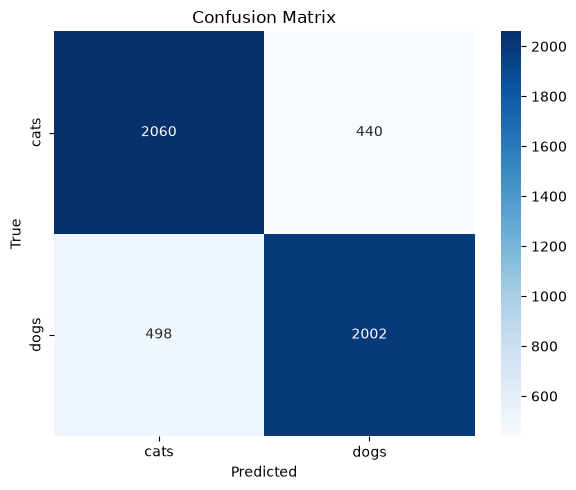

In [13]:
class_names = ["cats", "dogs"]

y_true = np.concatenate([labels.numpy().reshape(-1) for _, labels in test_ds]).astype(int)
y_prob = baseline_model.predict(test_ds, verbose=0).reshape(-1)
y_pred = (y_prob > 0.5).astype(int)

print("Accuracy: ", round(accuracy_score(y_true, y_pred), 4))
print("Precision:", round(precision_score(y_true, y_pred), 4))
print("Recall:   ", round(recall_score(y_true, y_pred), 4))
print("F1 score: ", round(f1_score(y_true, y_pred), 4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
